#Introduction to Dataset, DataLoader and Torchvision

In [1]:
#@markdown ---------------
#@markdown ## **⚠️❗ Ejecute esta celda para descargar Shoes dataset❗⚠️**
#@markdown ### Esta celda creará la carpeta ```/content/shoes_data```

!pip install -qq gdown
!gdown -qq "https://drive.google.com/uc?id=1_fIMm5nPp0BLJZKfkJZ_juRmLpRK4iA0" -O /shoes_data.zip
!mkdir /content/shoes_data/
!unzip -qq /shoes_data.zip -d /content/shoes_data
!rm -r /shoes_data.zip
print ("Done!")
#@markdown ---------------

Done!


In [2]:
import torch
from torch import nn #capas, metricas, modelos
from torchsummary import summary #imprimir resumen del modelo
from torchvision import datasets #objetos de db
from torchvision import transforms as T #objetos y operaciones math morfologicas para las imagenes
from torch.utils.data import DataLoader #

from PIL import Image #esta libreria porque esta basado en pilo
import numpy as np #
from tqdm import tqdm #
import matplotlib.pyplot as plt

In [5]:
#---- Importar librerias. Incluya acá todas las librerías que requiera
train_dataset = datasets.ImageFolder(root= "/content/shoes_data/train/" ) #image folder escane la carpeta y por cada una me crea
test_dataset = datasets.ImageFolder(root= "/content/shoes_data/test/" )
print (train_dataset) #se permite indexar
print (test_dataset)

Dataset ImageFolder
    Number of datapoints: 12000
    Root location: /content/shoes_data/train/
Dataset ImageFolder
    Number of datapoints: 3000
    Root location: /content/shoes_data/test/


(<PIL.Image.Image image mode=RGB size=136x102 at 0x7D9BC4388A40>, 1)


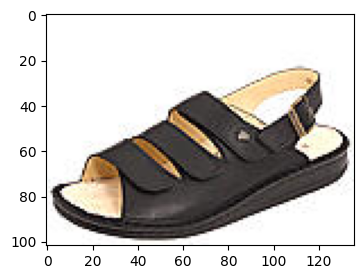

In [22]:
print ( train_dataset[4000] ) #las tuplas son las unicas que se imprimen en python en parentesis solo sirve para procesar solo una imagen a la vez

_, ax = plt.subplots(1,1, figsize = (4,3))
plt.imshow( train_dataset[4000][0] ) # el 4000 es el indice este devulve una img y un valor el valor es la clase

In [26]:
def plot_images(imgs, grid_size = (5,5)):
    #
    _, axs = plt.subplots(grid_size[0], grid_size[0], figsize = (grid_size[0]*4, grid_size[1]*4))
    axs = axs.ravel()

    for i, (img, ax) in enumerate(zip(imgs, axs)):
      if isinstance(img, torch.Tensor) : #is tensor? - la funcion isinstance compara un objeto inicial con le que le voy a entregar
        img = img.numpy()
      ax.imshow( img, cmap = 'gray' )
      ax.set_axis_off()

    plt.tight_layout()

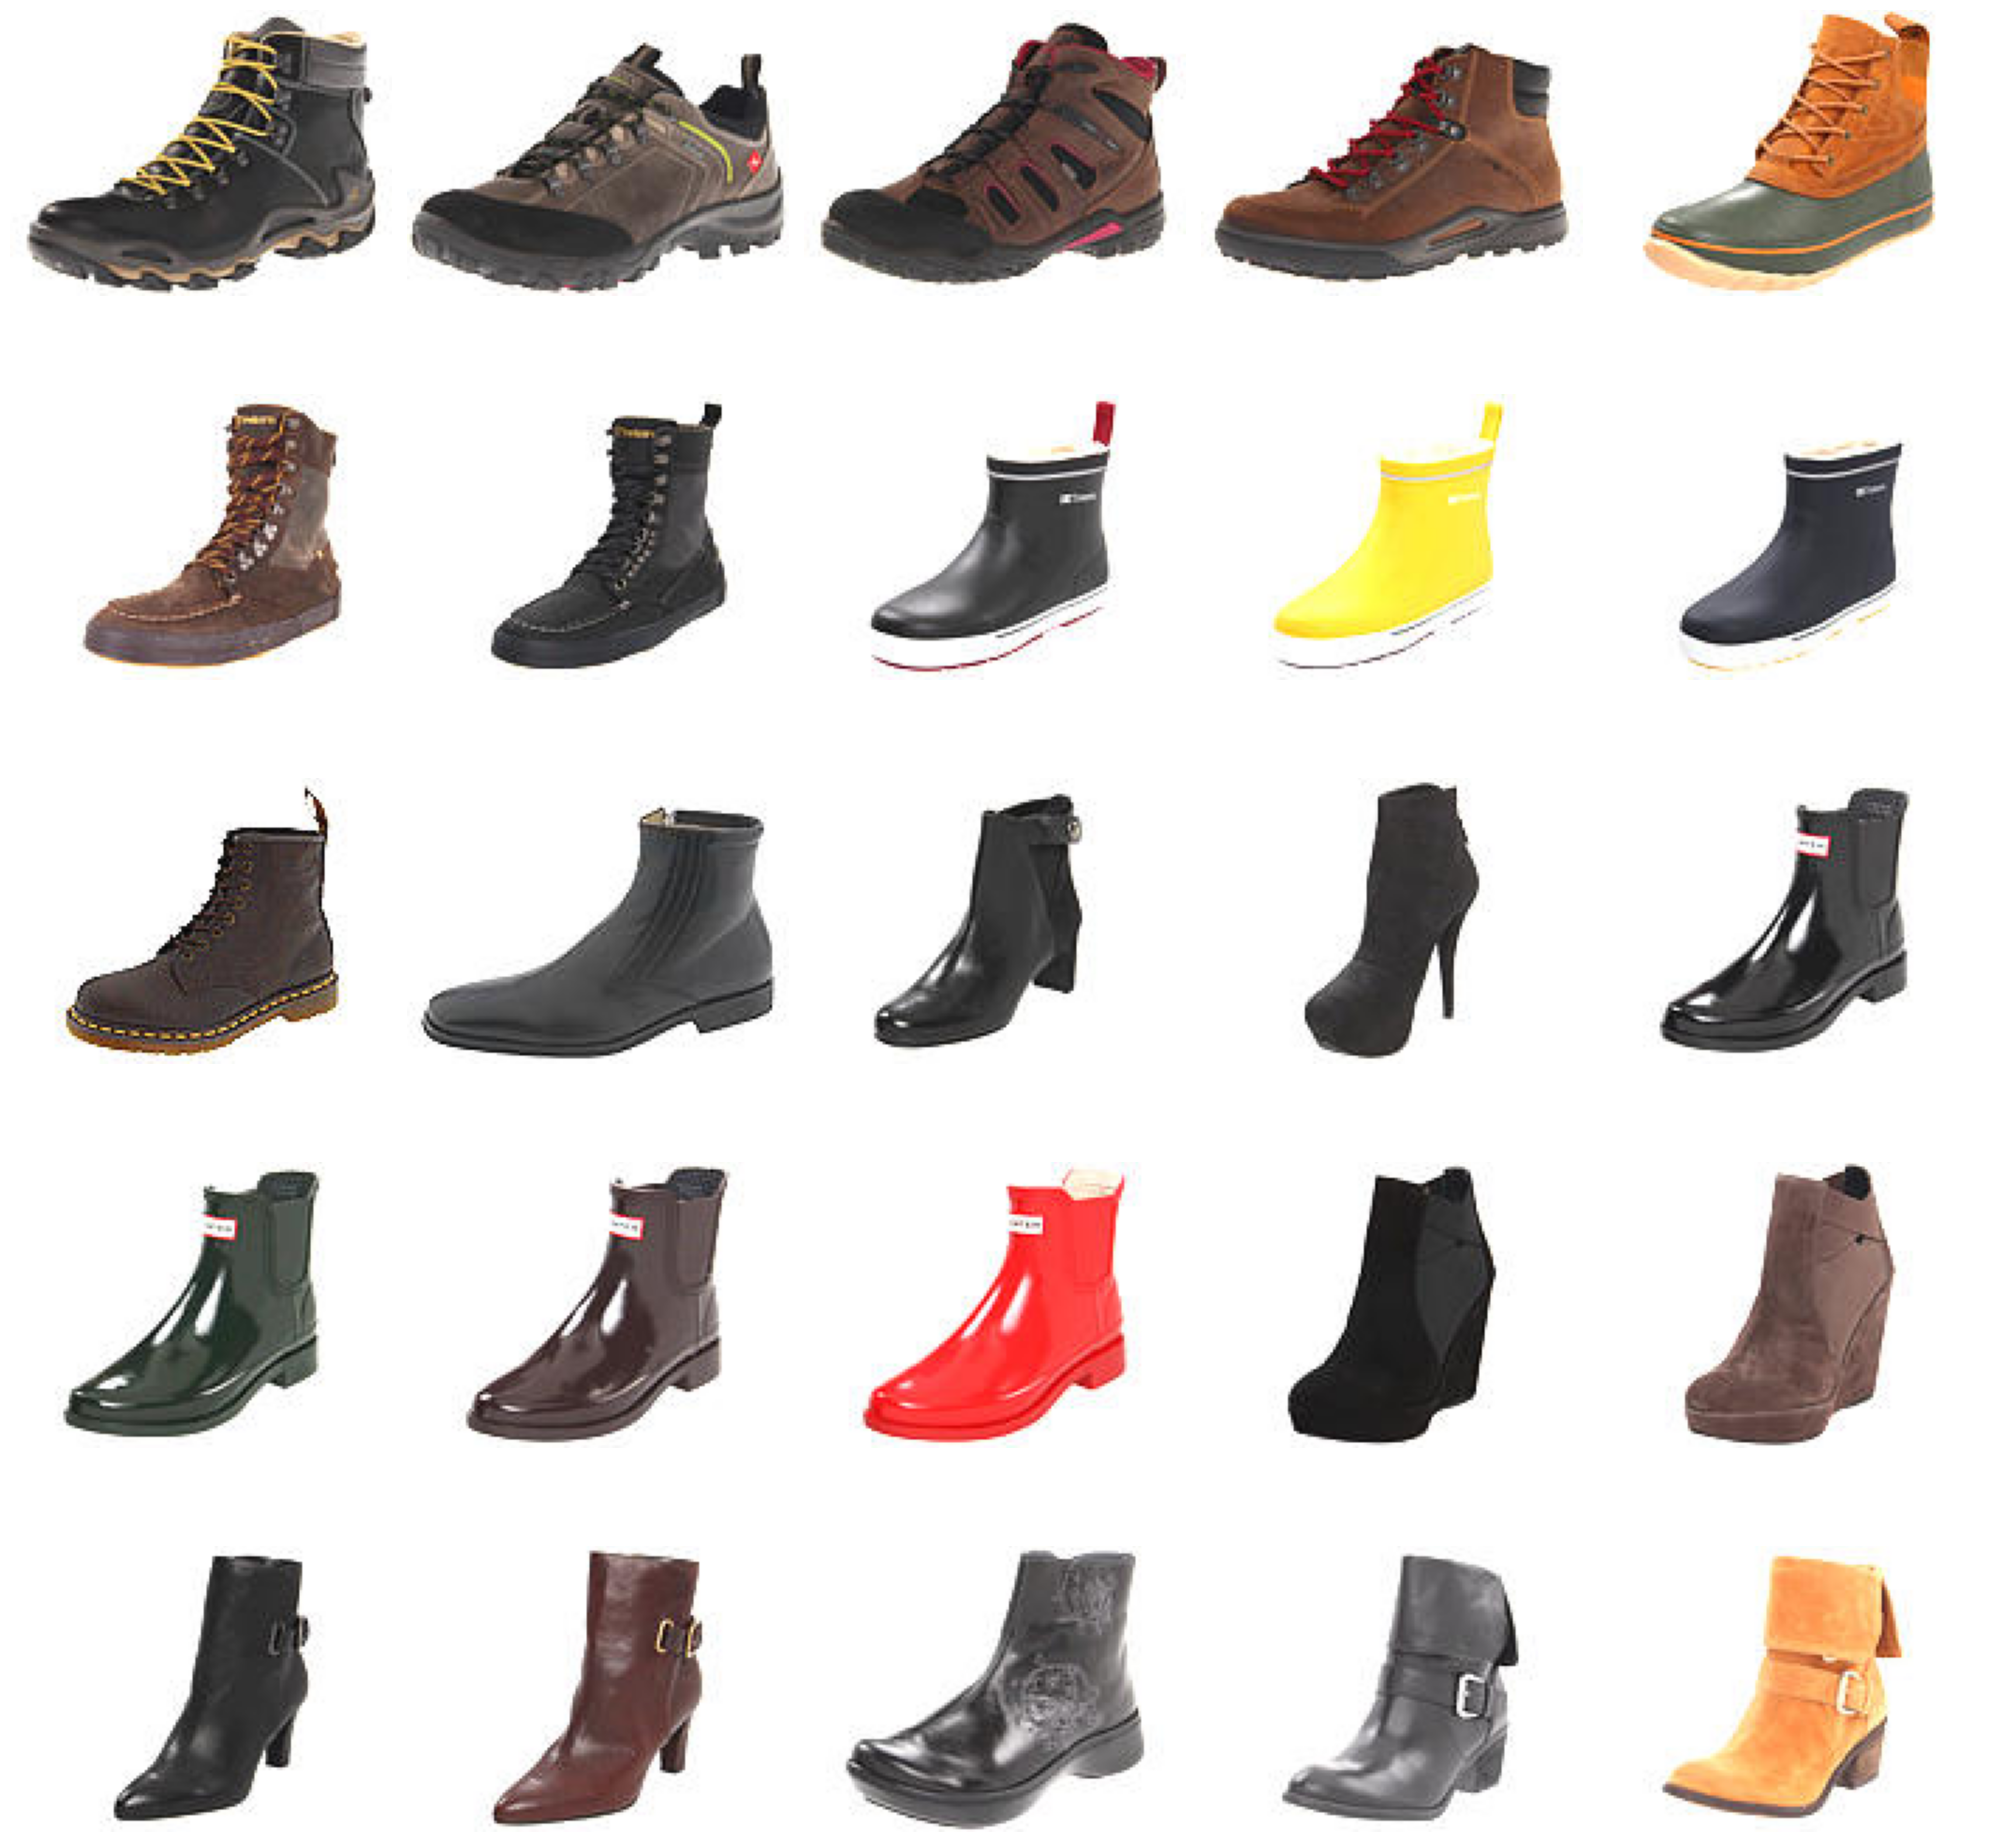

In [29]:
list_images = []
for i in range(990, 990+25):
  list_images.append( train_dataset[i][0] )

plot_images(list_images, grid_size=(5,5))

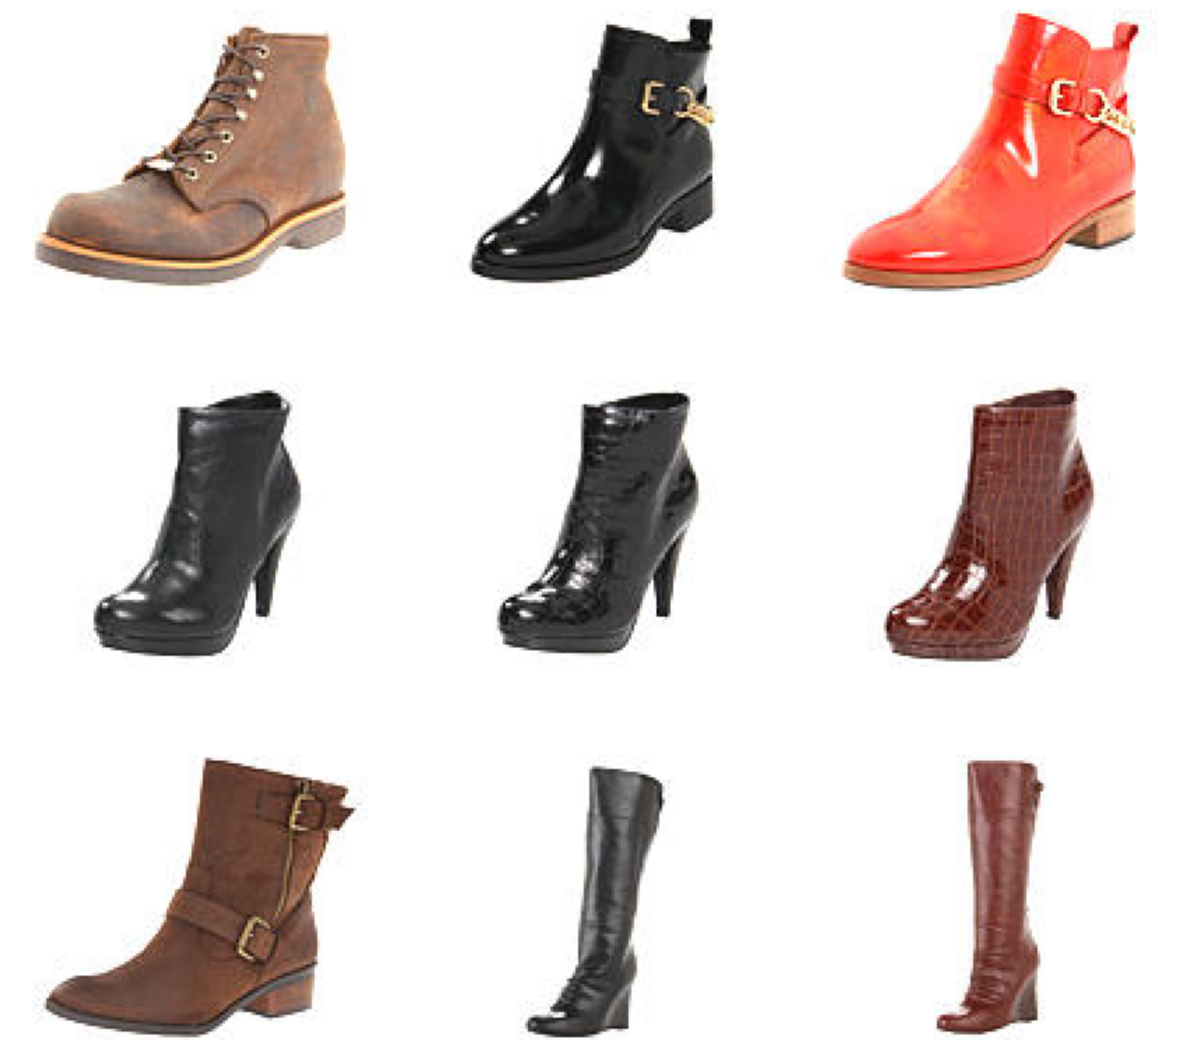

In [31]:
original_imgs = [ test_dataset[i][0] for i in range(9)]
plot_images (original_imgs, grid_size = (3,3))

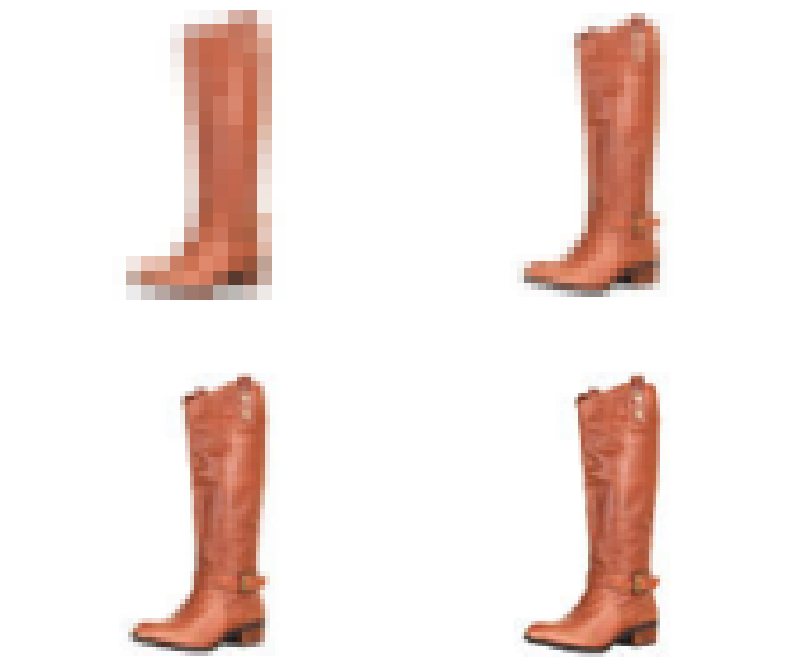

In [32]:
resized_imgs = [ T.Resize(size=size)( test_dataset[10][0] ) for size in (20,40,60,80)] #transformar el objeto resize - llamo al contructor para pedirme el size de redimensionamiento sin guardar el memoria le entro la imeg que quiero procesar
plot_images (resized_imgs, grid_size = (2,2))

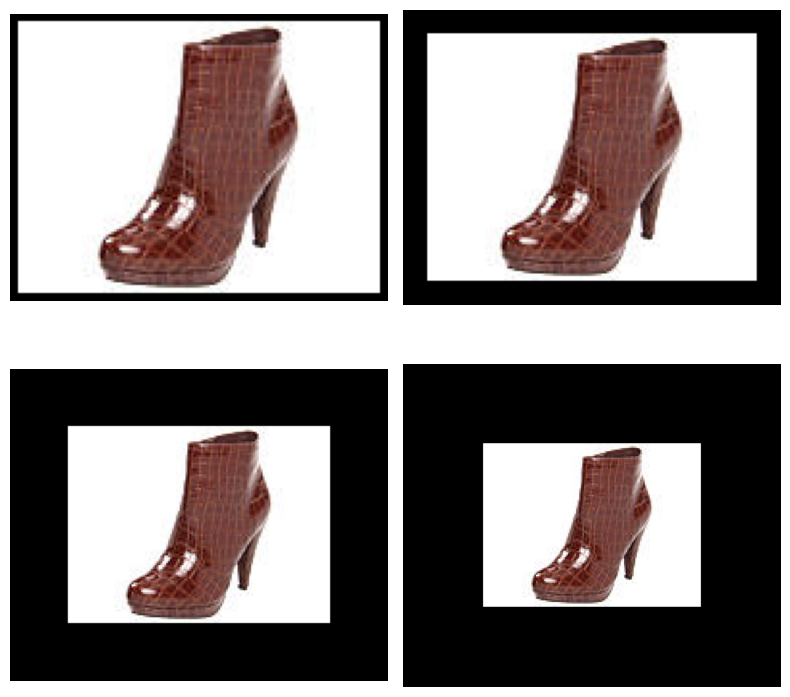

In [33]:
padded_imgs = [T.Pad(padding=padding)( test_dataset[5][0] )  for padding in (3, 10, 30, 50)] #anadir efecto de profunfidad, es un borde
plot_images (padded_imgs, grid_size = (2,2))

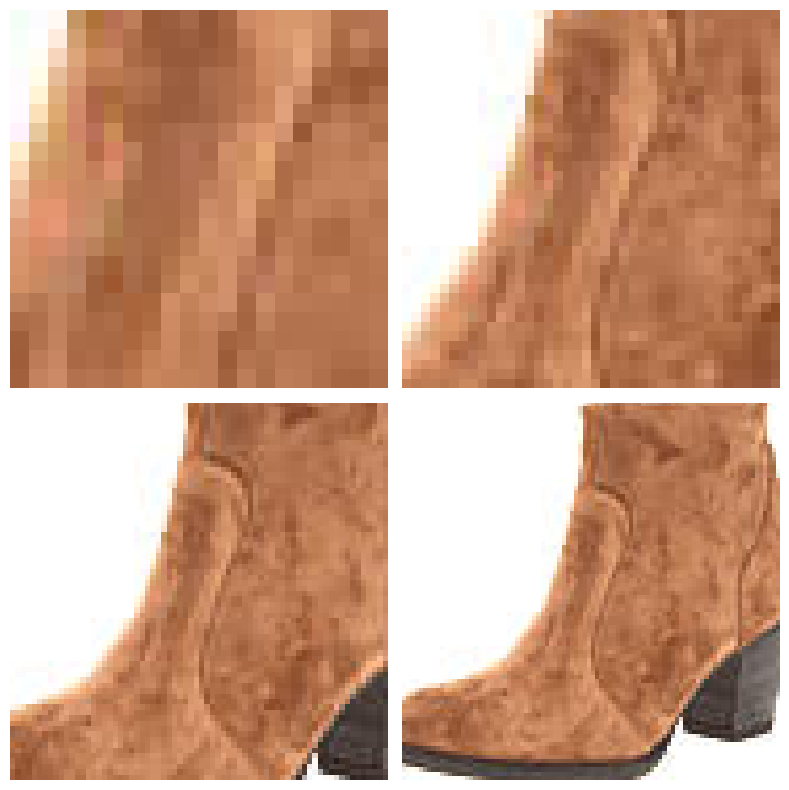

In [35]:
center_crops = [T.CenterCrop(size=size)( test_dataset[15][0]  ) for size in (20, 40, 70, 90)] # sacar un cuadro del centro de la imagen a partir del dataset
plot_images (center_crops, grid_size = (2,2))

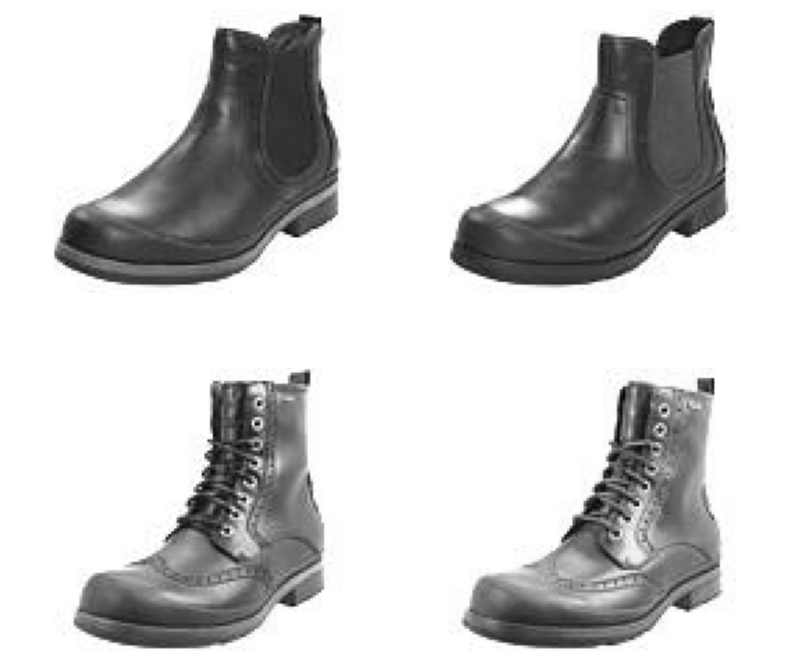

In [36]:
grayscale_imgs = [T.Grayscale()( test_dataset[i][0] ) for i in range(28, 32)] #escala de grises
plot_images (grayscale_imgs, grid_size = (2,2))

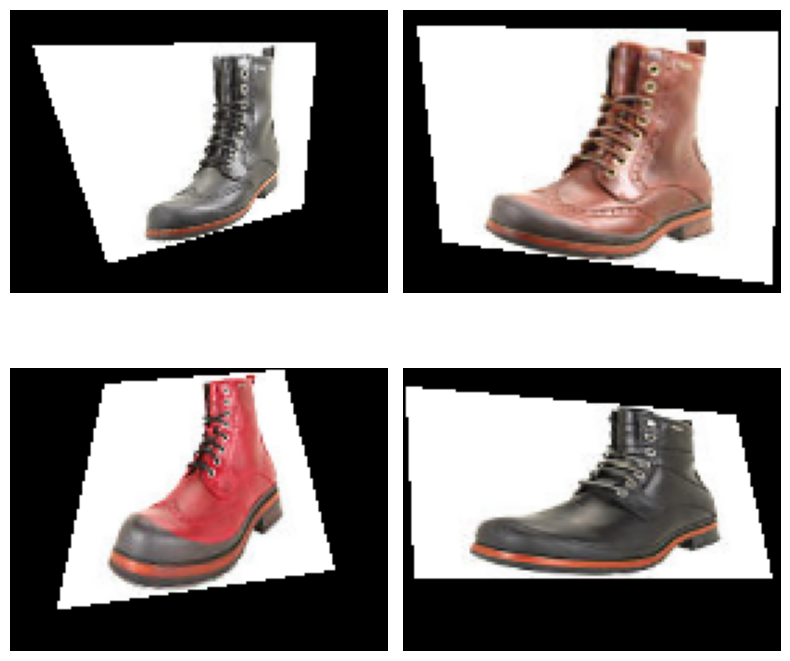

In [45]:
persp_imgs = [T.RandomPerspective(distortion_scale=0.6, p=1)( test_dataset[i][0] ) for i in range(30, 34)] #distorcion, deformacion de la imagen - value p es aleatorio las veces que se ejecute
plot_images (persp_imgs, grid_size = (2,2))

## Create a dataloader

In [55]:
image_transforms = T.Compose([T.Resize((64,64), Image.BICUBIC), #compose den transform crea un stack como una pila de la transformaciones que voy a realizar
                                       T.Pad(padding=5),
                              T.Grayscale(),
                              T.ToTensor()])

In [56]:
#---- Importar librerias. Incluya acá todas las librerías que requiera
train_dataset = datasets.ImageFolder(root= "/content/shoes_data/train/" , transform = image_transforms )
test_dataset = datasets.ImageFolder(root= "/content/shoes_data/test/" , transform = image_transforms )


In [60]:
print (train_dataset[0][0].shape)

torch.Size([1, 64, 64])

torch.Size([1, 74, 74])


torch.Size([1, 64, 64])

In [61]:
train_loader = DataLoader(train_dataset, batch_size= 50, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size= 50 )

In [62]:
trainBatch = next(iter(train_loader)) #devuelve los dos bachtes, etiquetas y
valBatch = next(iter(test_loader))

In [65]:
print (trainBatch[0].shape, valBatch[0].shape )
print (trainBatch[1].shape, valBatch[1].shape )


torch.Size([50, 1, 74, 74]) torch.Size([50, 1, 74, 74])
torch.Size([50]) torch.Size([50])


In [66]:
for i, (batch_X, batch_y) in enumerate(train_loader):
  print (i, batch_X.shape, batch_y.shape)
  if i == 5:
    break

0 torch.Size([50, 1, 74, 74]) torch.Size([50])
1 torch.Size([50, 1, 74, 74]) torch.Size([50])
2 torch.Size([50, 1, 74, 74]) torch.Size([50])
3 torch.Size([50, 1, 74, 74]) torch.Size([50])
4 torch.Size([50, 1, 74, 74]) torch.Size([50])
5 torch.Size([50, 1, 74, 74]) torch.Size([50])
